# 1 . Opciones vanilla: Monte Carlo GBM vs Black-Scholes cerrado

Este notebook construye calls y puts europeas como `Payoff` -- autoria programatica de AST
(`when`/`cashflow`/`maximum`/`fixing`, `PLAN_PRODUCTS.md SS7`) sobre un modelo `GBM` (medida
riesgo-neutral Q) -- y las valora con la medida Monte Carlo `PayoffPriceQ`. El objetivo es
doble: confirmar que el motor reproduce la teoria clasica (Black-Scholes, paridad put-call,
las Greeks de manual) y, a partir de ahi, mostrar como se construyen y visualizan curvas de
precio/Greeks frente a strike y spot -- el pan de cada dia de un desk de derivados.

Los notebooks siguientes de esta bateria exploran lo que Black-Scholes NO puede dar: barreras
y exoticos (`02`), ejercicio bermuda (`03`), superficies de sensibilidad de segundo orden
(`04`), medida fisica P (`05`) y exposicion/CVA/portfolio (`06`).

**Antes de ejecutar**, compila el proyecto con CMake (ver `PLAN.md` en la raiz del repo) --
el modulo `engine.cp3XX-....pyd`/`engine*.so` debe existir en `build/clients/python`.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, "../../../build/clients/python")
sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt

import engine
import engine_typed as q
from engine_typed import greeks

print("modulo engine importado desde:", engine.__file__)


modulo engine importado desde: S:\Projects\engine_quant\clients\python\notebooks\../../../build/clients/python\engine.cp312-win_amd64.pyd


## 1. Mercado y formulas cerradas de Black-Scholes

Reimplementamos Black-Scholes-Merton (con dividendo continuo `q`) en Python puro, solo para
contrastar -- el motor nunca usa esta formula, siempre revalora via simulacion Monte Carlo del
GBM (`PayoffPriceQ`).


In [2]:
import math


def _norm_cdf(x):
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))


def _norm_pdf(x):
    return math.exp(-0.5 * x * x) / math.sqrt(2.0 * math.pi)


def _d1_d2(s0, k, r, q_div, sigma, t):
    d1 = (math.log(s0 / k) + (r - q_div + 0.5 * sigma * sigma) * t) / (sigma * math.sqrt(t))
    d2 = d1 - sigma * math.sqrt(t)
    return d1, d2


def bs_call(s0, k, r, q_div, sigma, t):
    d1, d2 = _d1_d2(s0, k, r, q_div, sigma, t)
    return s0 * math.exp(-q_div * t) * _norm_cdf(d1) - k * math.exp(-r * t) * _norm_cdf(d2)


def bs_put(s0, k, r, q_div, sigma, t):
    d1, d2 = _d1_d2(s0, k, r, q_div, sigma, t)
    return k * math.exp(-r * t) * _norm_cdf(-d2) - s0 * math.exp(-q_div * t) * _norm_cdf(-d1)


def bs_greeks_call(s0, k, r, q_div, sigma, t):
    d1, d2 = _d1_d2(s0, k, r, q_div, sigma, t)
    delta = math.exp(-q_div * t) * _norm_cdf(d1)
    gamma = math.exp(-q_div * t) * _norm_pdf(d1) / (s0 * sigma * math.sqrt(t))
    vega = s0 * math.exp(-q_div * t) * _norm_pdf(d1) * math.sqrt(t)
    theta = (
        -s0 * math.exp(-q_div * t) * _norm_pdf(d1) * sigma / (2.0 * math.sqrt(t))
        - r * k * math.exp(-r * t) * _norm_cdf(d2)
        + q_div * s0 * math.exp(-q_div * t) * _norm_cdf(d1)
    )
    rho = k * t * math.exp(-r * t) * _norm_cdf(d2)
    return {"delta": delta, "gamma": gamma, "vega": vega, "theta": theta, "rho": rho}


S0, R, Q_DIV, SIGMA, T = 100.0, 0.05, 0.015, 0.20, 1.0
OBS = "EQ.SPOT.DEMO"

eng = engine.Engine()
model = eng.create_model("GBM", {"s0": S0, "r": R, "q": Q_DIV, "sigma": SIGMA, "observable": OBS})
market = engine.MarketSnapshot(pillars=[T], zero_rates=[R])
execution = engine.ExecutionContext({"backend": "cpu"})
pricing_hi = engine.PricingContext({"pricing_date": 0.0, "n_paths": 500_000.0, "n_steps": 1.0, "seed": 7.0})
pricing_sweep = engine.PricingContext({"pricing_date": 0.0, "n_paths": 40_000.0, "n_steps": 1.0, "seed": 7.0})

print(f"S0={S0}  r={R:.1%}  q={Q_DIV:.1%}  sigma={SIGMA:.1%}  T={T}y")


S0=100.0  r=5.0%  q=1.5%  sigma=20.0%  T=1.0y


## 2. Precio ATM: motor Monte Carlo vs formula cerrada


In [3]:
K_ATM = S0
call = q.european_call("CALL_ATM", OBS, strike=K_ATM, notional=1.0, maturity=T)
put = q.european_put("PUT_ATM", OBS, strike=K_ATM, notional=1.0, maturity=T)

call_product = eng.create_product(call.product_type, call.to_params())
put_product = eng.create_product(put.product_type, put.to_params())

mc_call = eng.price(call_product, ["PayoffPriceQ"], model, market, pricing_hi, execution)["PayoffPriceQ"].scalar
mc_put = eng.price(put_product, ["PayoffPriceQ"], model, market, pricing_hi, execution)["PayoffPriceQ"].scalar
bs_c = bs_call(S0, K_ATM, R, Q_DIV, SIGMA, T)
bs_p = bs_put(S0, K_ATM, R, Q_DIV, SIGMA, T)

print(f"{'':10}{'Monte Carlo':>14}{'Black-Scholes':>16}{'diff':>10}")
print(f"{'Call':10}{mc_call:14.4f}{bs_c:16.4f}{mc_call - bs_c:10.4f}")
print(f"{'Put':10}{mc_put:14.4f}{bs_p:16.4f}{mc_put - bs_p:10.4f}")


             Monte Carlo   Black-Scholes      diff
Call              9.5076          9.5235   -0.0159
Put               6.1573          6.1353    0.0220


## 3. Diagrama de payoff a vencimiento


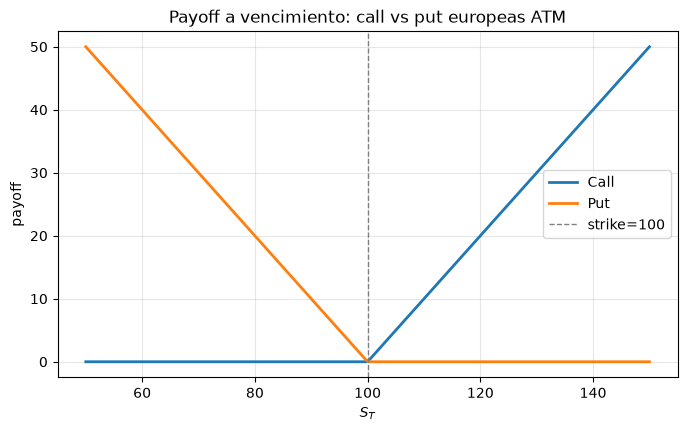

In [4]:
s_grid = np.linspace(0.5 * S0, 1.5 * S0, 200)
payoff_call = np.maximum(s_grid - K_ATM, 0.0)
payoff_put = np.maximum(K_ATM - s_grid, 0.0)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(s_grid, payoff_call, label="Call", linewidth=2)
ax.plot(s_grid, payoff_put, label="Put", linewidth=2)
ax.axvline(K_ATM, color="grey", linestyle="--", linewidth=1, label=f"strike={K_ATM:.0f}")
ax.set_xlabel("$S_T$")
ax.set_ylabel("payoff")
ax.set_title("Payoff a vencimiento: call vs put europeas ATM")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


## 4. Curva de precio frente a strike (`price_many`, una sola simulacion por lote)

`price_many` agrupa internamente por calendario y comparte la simulacion Monte Carlo del
tipo corto/spot entre todos los trades del lote -- una sola pasada Monte Carlo basta para
los 13 strikes de cada lado, en vez de 13 llamadas independientes a `Engine.price`.


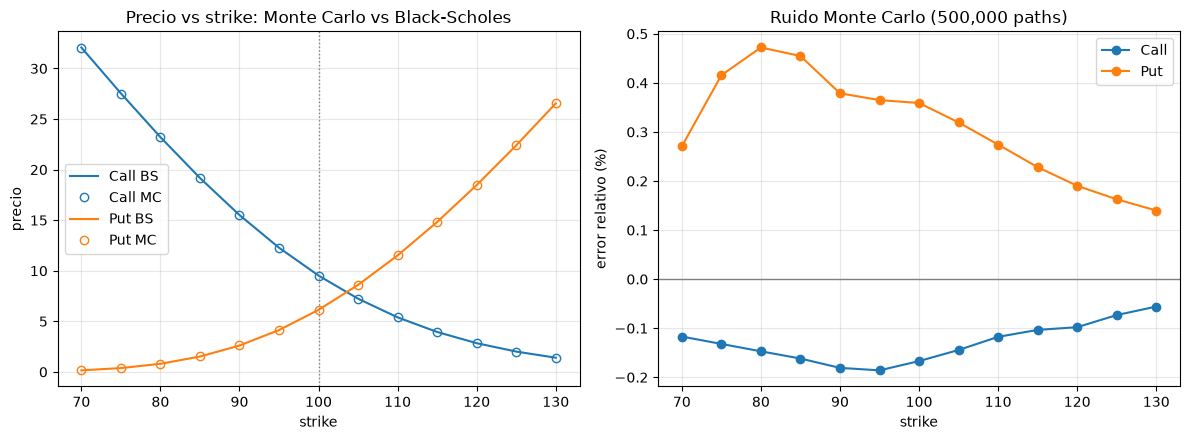

In [5]:
strikes = np.arange(70.0, 131.0, 5.0)

call_products, put_products = [], []
for k in strikes:
    c = q.european_call(f"CALL_{k:.0f}", OBS, strike=float(k), notional=1.0, maturity=T)
    p = q.european_put(f"PUT_{k:.0f}", OBS, strike=float(k), notional=1.0, maturity=T)
    call_products.append(eng.create_product(c.product_type, c.to_params()))
    put_products.append(eng.create_product(p.product_type, p.to_params()))

call_rows = eng.price_many(call_products, ["PayoffPriceQ"], model, market, pricing_hi, execution)
put_rows = eng.price_many(put_products, ["PayoffPriceQ"], model, market, pricing_hi, execution)

mc_call_curve = np.array([row.measures["PayoffPriceQ"].scalar for row in call_rows])
mc_put_curve = np.array([row.measures["PayoffPriceQ"].scalar for row in put_rows])
bs_call_curve = np.array([bs_call(S0, k, R, Q_DIV, SIGMA, T) for k in strikes])
bs_put_curve = np.array([bs_put(S0, k, R, Q_DIV, SIGMA, T) for k in strikes])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(strikes, bs_call_curve, "-", color="tab:blue", label="Call BS")
axes[0].plot(strikes, mc_call_curve, "o", color="tab:blue", markerfacecolor="none", label="Call MC")
axes[0].plot(strikes, bs_put_curve, "-", color="tab:orange", label="Put BS")
axes[0].plot(strikes, mc_put_curve, "o", color="tab:orange", markerfacecolor="none", label="Put MC")
axes[0].axvline(S0, color="grey", linestyle=":", linewidth=1)
axes[0].set_xlabel("strike")
axes[0].set_ylabel("precio")
axes[0].set_title("Precio vs strike: Monte Carlo vs Black-Scholes")
axes[0].legend()
axes[0].grid(alpha=0.3)

rel_err_call = (mc_call_curve - bs_call_curve) / bs_call_curve * 100.0
rel_err_put = (mc_put_curve - bs_put_curve) / bs_put_curve * 100.0
axes[1].plot(strikes, rel_err_call, "o-", label="Call")
axes[1].plot(strikes, rel_err_put, "o-", label="Put")
axes[1].axhline(0.0, color="grey", linewidth=1)
axes[1].set_xlabel("strike")
axes[1].set_ylabel("error relativo (%)")
axes[1].set_title("Ruido Monte Carlo (500,000 paths)")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Paridad put-call como cheque de consistencia


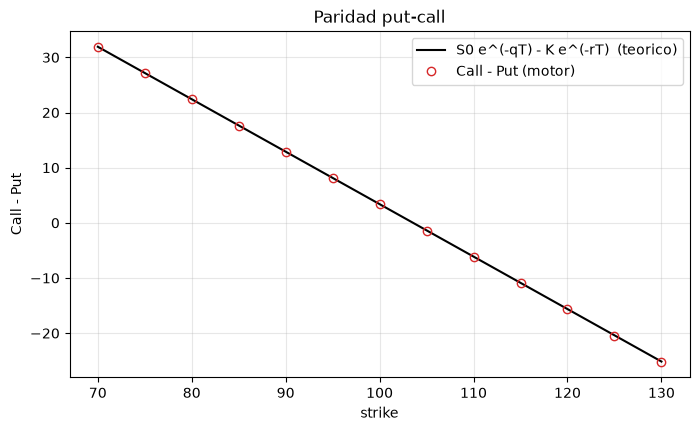

Maxima desviacion de la paridad put-call en la rejilla de strikes: 0.0379


In [6]:
parity_lhs = mc_call_curve - mc_put_curve
parity_rhs = S0 * math.exp(-Q_DIV * T) - strikes * math.exp(-R * T)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(strikes, parity_rhs, "-", color="black", label="S0 e^(-qT) - K e^(-rT)  (teorico)")
ax.plot(strikes, parity_lhs, "o", color="tab:red", markerfacecolor="none", label="Call - Put (motor)")
ax.set_xlabel("strike")
ax.set_ylabel("Call - Put")
ax.set_title("Paridad put-call")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

max_abs_diff = float(np.max(np.abs(parity_lhs - parity_rhs)))
print(f"Maxima desviacion de la paridad put-call en la rejilla de strikes: {max_abs_diff:.4f}")


## 6. Greeks de la call ATM: `engine_typed.greeks` vs Black-Scholes

`greeks.theta(...)` (PLAN_GREEKS.md SS7.1, PLAN_IMPROVE_NOTEBOOK.md Fase 4/ADR-IN-01) tiene una
convencion explicita en su propio docstring/API, ya no hay que redescubrirla comparando contra
Black-Scholes:

- `annualized=False` (default): devuelve el DeltaV CRUDO de un unico bump `dt` (un dia por
  defecto, resuelto internamente por el motor) -- `V(t+dt) - V(t)`, sin dividir por `dt`. Es la
  UNICA Greek con esta convencion (delta/gamma/vega/rho si son derivadas propiamente
  normalizadas por el tamano del bump).
- `annualized=True`: devuelve `DeltaV / dt`, la derivada anualizada `dV/dt` -- comparable
  directamente con el theta anualizado de la formula cerrada, sin escalar nada a mano. El
  escalado lo aplica `ThetaGreek.annualize(...)` en Python sobre el `MeasureResult` que ya
  devolvio el motor, leyendo `bump_used` de ahi (PLAN_IMPROVE_NOTEBOOK2.md Fase 5: el bump
  EFECTIVAMENTE usado por el motor, ya no una constante Python duplicada).

Abajo se comparan ambas convenciones contra Black-Scholes en la misma tabla.


In [7]:
delta_mc = eng.price(call_product, [greeks.delta("PayoffPriceQ", "spot").to_spec()], model, market, pricing_hi, execution)["Greek"].scalar
gamma_mc = eng.price(call_product, [greeks.gamma("PayoffPriceQ", "spot").to_spec()], model, market, pricing_hi, execution)["Greek"].scalar
vega_mc = eng.price(call_product, [greeks.vega("PayoffPriceQ").to_spec()], model, market, pricing_hi, execution)["Greek"].scalar
rho_mc = eng.price(call_product, [greeks.rho("PayoffPriceQ").to_spec()], model, market, pricing_hi, execution)["Greek"].scalar

theta_raw_greek = greeks.theta("PayoffPriceQ")
theta_raw_result = eng.price(call_product, [theta_raw_greek.to_spec()], model, market, pricing_hi, execution)["Greek"]
theta_raw_mc = theta_raw_greek.annualize(theta_raw_result)

theta_annualized_greek = greeks.theta("PayoffPriceQ", annualized=True)
theta_annualized_result = eng.price(call_product, [theta_annualized_greek.to_spec()], model, market, pricing_hi, execution)["Greek"]
theta_annualized_mc = theta_annualized_greek.annualize(theta_annualized_result)

bs_g = bs_greeks_call(S0, K_ATM, R, Q_DIV, SIGMA, T)
rows = [
    ("delta", delta_mc, bs_g["delta"]),
    ("gamma", gamma_mc, bs_g["gamma"]),
    ("vega", vega_mc, bs_g["vega"]),
    # PLAN_IMPROVE_NOTEBOOK2.md Fase 5: el bump crudo de comparacion sale de
    # MeasureResult.bump_used (el que REALMENTE uso el motor), no de una constante Python.
    ("theta (1 dia, crudo)", theta_raw_mc, bs_g["theta"] * theta_raw_result.bump_used),
    ("theta (anualizado)", theta_annualized_mc, bs_g["theta"]),
    ("rho", rho_mc, bs_g["rho"]),
]
print(f"{'greek':22}{'motor (MC)':>14}{'Black-Scholes':>16}")
for name, mc_value, bs_value in rows:
    print(f"{name:22}{mc_value:14.5f}{bs_value:16.5f}")


greek                     motor (MC)   Black-Scholes
delta                        0.59763         0.59928
gamma                        0.01886         0.01892
vega                        37.79772        37.84198
theta (1 dia, crudo)        -0.01479        -0.01481
theta (anualizado)          -5.39911        -5.40552
rho                         50.25497        50.40495


## 7. Perfil de Greeks frente al spot


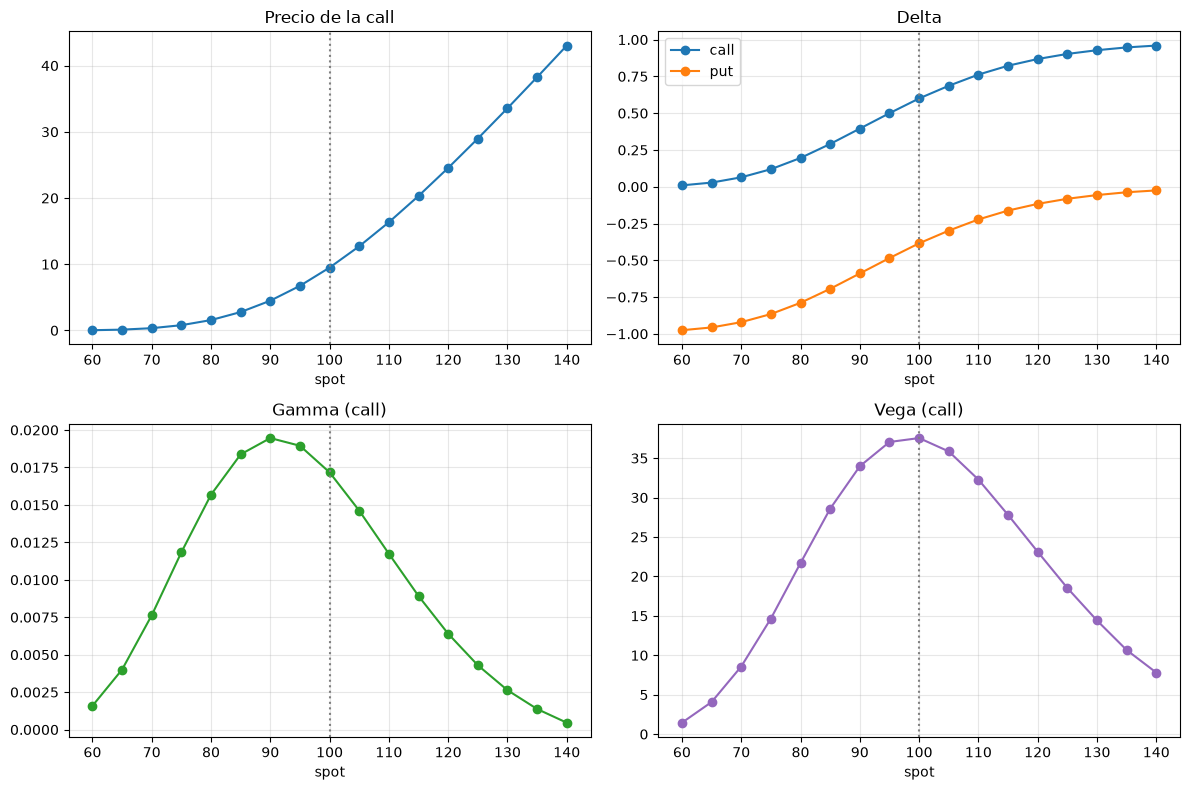

In [8]:
spot_grid = np.linspace(0.6 * S0, 1.4 * S0, 17)
deltas_call, deltas_put, gammas, vegas, prices_call = [], [], [], [], []

for s in spot_grid:
    m = eng.create_model("GBM", {"s0": float(s), "r": R, "q": Q_DIV, "sigma": SIGMA, "observable": OBS})
    deltas_call.append(eng.price(call_product, [greeks.delta("PayoffPriceQ", "spot").to_spec()], m, market, pricing_sweep, execution)["Greek"].scalar)
    deltas_put.append(eng.price(put_product, [greeks.delta("PayoffPriceQ", "spot").to_spec()], m, market, pricing_sweep, execution)["Greek"].scalar)
    gammas.append(eng.price(call_product, [greeks.gamma("PayoffPriceQ", "spot").to_spec()], m, market, pricing_sweep, execution)["Greek"].scalar)
    vegas.append(eng.price(call_product, [greeks.vega("PayoffPriceQ").to_spec()], m, market, pricing_sweep, execution)["Greek"].scalar)
    prices_call.append(eng.price(call_product, ["PayoffPriceQ"], m, market, pricing_sweep, execution)["PayoffPriceQ"].scalar)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].plot(spot_grid, prices_call, "o-", color="tab:blue")
axes[0, 0].axvline(K_ATM, color="grey", linestyle=":")
axes[0, 0].set_title("Precio de la call")
axes[0, 1].plot(spot_grid, deltas_call, "o-", label="call")
axes[0, 1].plot(spot_grid, deltas_put, "o-", label="put")
axes[0, 1].axvline(K_ATM, color="grey", linestyle=":")
axes[0, 1].set_title("Delta")
axes[0, 1].legend()
axes[1, 0].plot(spot_grid, gammas, "o-", color="tab:green")
axes[1, 0].axvline(K_ATM, color="grey", linestyle=":")
axes[1, 0].set_title("Gamma (call)")
axes[1, 1].plot(spot_grid, vegas, "o-", color="tab:purple")
axes[1, 1].axvline(K_ATM, color="grey", linestyle=":")
axes[1, 1].set_title("Vega (call)")
for ax in axes.flat:
    ax.set_xlabel("spot")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
